In [2]:
import pandas as pd
import numpy as np

# Load the provided dataset
df = pd.read_csv("../data/Nassau Candy Distributor.csv")

print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (10194, 18)


In [3]:
# Display first 5 rows
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Country/Region,City,State/Province,Postal Code,Division,Region,Product ID,Product Name,Sales,Units,Gross Profit,Cost
0,1,US-2021-103800-CHO-MIL-31000,03-01-2024,30-06-2026,Standard Class,103800,United States,Houston,Texas,77095,Chocolate,Interior,CHO-MIL-31000,Wonka Bar - Milk Chocolate,6.50,2,4.22,2.28
1,2,US-2021-112326-CHO-TRI-54000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,7.50,2,4.90,2.60
2,3,US-2021-112326-CHO-NUT-13000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-NUT-13000,Wonka Bar - Nutty Crunch Surprise,10.47,3,7.47,3.00
3,4,US-2021-112326-CHO-SCR-58000,04-01-2024,01-07-2026,Standard Class,112326,United States,Naperville,Illinois,60540,Chocolate,Interior,CHO-SCR-58000,Wonka Bar -Scrumdiddlyumptious,10.80,3,7.50,3.30
4,5,US-2021-141817-CHO-TRI-54000,05-01-2024,05-07-2026,Standard Class,141817,United States,Philadelphia,Pennsylvania,19143,Chocolate,Atlantic,CHO-TRI-54000,Wonka Bar - Triple Dazzle Caramel,11.25,3,7.35,3.90


In [4]:
# Display all column names
print("Columns:")
for i, column in enumerate(df.columns, 1):
    print(f"{i}. {column}")

Columns:
1. Row ID
2. Order ID
3. Order Date
4. Ship Date
5. Ship Mode
6. Customer ID
7. Country/Region
8. City
9. State/Province
10. Postal Code
11. Division
12. Region
13. Product ID
14. Product Name
15. Sales
16. Units
17. Gross Profit
18. Cost


In [5]:
# Basic dataset information
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10194 entries, 0 to 10193
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Row ID          10194 non-null  int64  
 1   Order ID        10194 non-null  str    
 2   Order Date      10194 non-null  str    
 3   Ship Date       10194 non-null  str    
 4   Ship Mode       10194 non-null  str    
 5   Customer ID     10194 non-null  int64  
 6   Country/Region  10194 non-null  str    
 7   City            10194 non-null  str    
 8   State/Province  10194 non-null  str    
 9   Postal Code     10194 non-null  str    
 10  Division        10194 non-null  str    
 11  Region          10194 non-null  str    
 12  Product ID      10194 non-null  str    
 13  Product Name    10194 non-null  str    
 14  Sales           10194 non-null  float64
 15  Units           10194 non-null  int64  
 16  Gross Profit    10194 non-null  float64
 17  Cost            10194 non-null  float64
dt

In [6]:
# ==========================================
# DATA QUALITY & BUSINESS VALIDATION
# ==========================================

# 1. Check duplicate rows
print("Duplicate rows:", df.duplicated().sum())

# 2. Convert dates
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="%d-%m-%Y",
    errors="coerce"
)

# 3. Check invalid dates
print("Invalid Order Dates:", df["Order Date"].isna().sum())
print("Invalid Ship Dates:", df["Ship Date"].isna().sum())

# 4. Create shipping lead time
df["Lead Time"] = (
    df["Ship Date"] - df["Order Date"]
).dt.days

print("\nLead Time Summary:")
print(df["Lead Time"].describe())

# 5. Check impossible lead times
print("\nNegative Lead Times:", (df["Lead Time"] < 0).sum())

# 6. Check financial values
print("\nSales <= 0:", (df["Sales"] <= 0).sum())
print("Units <= 0:", (df["Units"] <= 0).sum())
print("Cost < 0:", (df["Cost"] < 0).sum())

# 7. Check profit calculation
profit_difference = (
    df["Sales"] - df["Cost"] - df["Gross Profit"]
).abs()

print(
    "\nGross Profit calculation mismatches:",
    (profit_difference > 0.01).sum()
)

print("\nData validation completed.")

Duplicate rows: 0
Invalid Order Dates: 0
Invalid Ship Dates: 0

Lead Time Summary:
count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64

Negative Lead Times: 0

Sales <= 0: 0
Units <= 0: 0
Cost < 0: 0

Gross Profit calculation mismatches: 0

Data validation completed.


In [ ]:
# ==========================================
# LEAD TIME INVESTIGATION
# ==========================================

print("Order Date range:")
print(df["Order Date"].min(), "to", df["Order Date"].max())

print("\nShip Date range:")
print(df["Ship Date"].min(), "to", df["Ship Date"].max())

print("\nMost common lead times:")
print(df["Lead Time"].value_counts().head(15))

print("\nLead time by Ship Mode:")
print(
    df.groupby("Ship Mode")["Lead Time"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

print("\nLead time by Region:")
print(
    df.groupby("Region")["Lead Time"]
    .agg(["count", "mean", "median", "min", "max"])
    .round(2)
)

Order Date range:
2024-01-02 00:00:00 to 2025-12-31 00:00:00

Ship Date range:
2026-06-30 00:00:00 to 2030-06-28 00:00:00

Most common lead times:
Lead Time
1273    1326
1274    1035
1639     896
1640     657
1275     612
1271     610
908      591
909      519
1272     456
1637     449
1638     411
1641     397
1276     293
906      289
1269     258
Name: count, dtype: int64

Lead time by Ship Mode:
                count     mean  median  min   max
Ship Mode                                        
First Class      1548  1338.28  1272.0  905  1638
Same Day          547  1333.44  1269.0  904  1636
Second Class     1979  1323.85  1273.0  906  1640
Standard Class   6120  1314.33  1274.0  908  1642

Lead time by Region:
          count     mean  median  min   max
Region                                     
Atlantic   2986  1322.75  1274.0  904  1642
Gulf       1620  1311.37  1274.0  904  1642
Interior   2335  1323.09  1274.0  904  1642
Pacific    3253  1322.19  1274.0  904  1642


In [8]:
# ==========================================
# BUSINESS DATA PROFILE
# ==========================================

print("===== SHIP MODE =====")
print(df["Ship Mode"].value_counts())

print("\n===== DIVISION =====")
print(df["Division"].value_counts())

print("\n===== REGION =====")
print(df["Region"].value_counts())

print("\n===== PRODUCTS =====")
print("Number of unique products:", df["Product Name"].nunique())
print(df["Product Name"].value_counts())

print("\n===== CUSTOMERS =====")
print("Unique customers:", df["Customer ID"].nunique())

print("\n===== ORDERS =====")
print("Unique orders:", df["Order ID"].nunique())

===== SHIP MODE =====
Ship Mode
Standard Class    6120
Second Class      1979
First Class       1548
Same Day           547
Name: count, dtype: int64

===== DIVISION =====
Division
Chocolate    9844
Other         310
Sugar          40
Name: count, dtype: int64

===== REGION =====
Region
Pacific     3253
Atlantic    2986
Interior    2335
Gulf        1620
Name: count, dtype: int64

===== PRODUCTS =====
Number of unique products: 15
Product Name
Wonka Bar - Milk Chocolate           2137
Wonka Bar -Scrumdiddlyumptious       2064
Wonka Bar - Triple Dazzle Caramel    2015
Wonka Bar - Fudge Mallows            1818
Wonka Bar - Nutty Crunch Surprise    1810
Wonka Gum                             120
Kazookles                              96
Lickable Wallpaper                     94
Laffy Taffy                            10
SweeTARTS                              10
Fizzy Lifting Drinks                    6
Nerds                                   4
Hair Toffee                             4
Everlas

In [9]:
# ==========================================
# FEATURE ENGINEERING
# ==========================================

# Date-based features
df["Order Year"] = df["Order Date"].dt.year
df["Order Month"] = df["Order Date"].dt.month
df["Order Quarter"] = df["Order Date"].dt.quarter

# Profit margin
df["Profit Margin"] = (
    df["Gross Profit"] / df["Sales"]
) * 100

# Sales per unit
df["Sales per Unit"] = (
    df["Sales"] / df["Units"]
)

# Cost per unit
df["Cost per Unit"] = (
    df["Cost"] / df["Units"]
)

print("New features created successfully!")

print("\nNew columns:")
print([
    "Order Year",
    "Order Month",
    "Order Quarter",
    "Profit Margin",
    "Sales per Unit",
    "Cost per Unit",
    "Lead Time"
])

print("\nFeature preview:")
display(
    df[
        [
            "Product Name",
            "Region",
            "Ship Mode",
            "Lead Time",
            "Sales",
            "Units",
            "Gross Profit",
            "Profit Margin"
        ]
    ].head()
)

New features created successfully!

New columns:
['Order Year', 'Order Month', 'Order Quarter', 'Profit Margin', 'Sales per Unit', 'Cost per Unit', 'Lead Time']

Feature preview:


,Product Name,Region,Ship Mode,Lead Time,Sales,Units,Gross Profit,Profit Margin
0,Wonka Bar - Milk Chocolate,Interior,Standard Class,909,6.50,2,4.22,64.923077
1,Wonka Bar - Triple Dazzle Caramel,Interior,Standard Class,909,7.50,2,4.90,65.333333
2,Wonka Bar - Nutty Crunch Surprise,Interior,Standard Class,909,10.47,3,7.47,71.346705
3,Wonka Bar -Scrumdiddlyumptious,Interior,Standard Class,909,10.80,3,7.50,69.444444
4,Wonka Bar - Triple Dazzle Caramel,Atlantic,Standard Class,912,11.25,3,7.35,65.333333


In [10]:
# ==========================================
# PRODUCT & PROFITABILITY ANALYSIS
# ==========================================

product_analysis = (
    df.groupby("Product Name")
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Units", "sum"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Cost=("Cost", "sum"),
          Avg_Lead_Time=("Lead Time", "mean")
      )
      .sort_values("Sales", ascending=False)
)

product_analysis["Profit_Margin_%"] = (
    product_analysis["Gross_Profit"] /
    product_analysis["Sales"] * 100
)

product_analysis = product_analysis.round(2)

display(product_analysis)

,Orders,Units,Sales,Gross_Profit,Cost,Avg_Lead_Time,Profit_Margin_%
Product Name,,,,,,,
Wonka Bar - Triple Dazzle Caramel,1677,7596,28485.00,18610.20,9874.80,1325.66,65.33
Wonka Bar -Scrumdiddlyumptious,1704,7743,27874.80,19357.50,8517.30,1320.64,69.44
Wonka Bar - Milk Chocolate,1768,8267,26867.75,17443.37,9424.38,1316.76,64.92
Wonka Bar - Fudge Mallows,1527,6914,24890.40,16593.60,8296.80,1314.24,66.67
Wonka Bar - Nutty Crunch Surprise,1529,6755,23574.95,16819.95,6755.00,1328.92,71.35
Lickable Wallpaper,92,393,7860.00,3930.00,3930.00,1339.14,50.00
Kazookles,94,371,1205.75,92.75,1113.00,1272.99,7.69
Wonka Gum,118,478,597.50,310.70,286.80,1306.53,52.00
Everlasting Gobstopper,3,13,130.00,104.00,26.00,1394.67,80.00


In [11]:
# Top products by sales
print("===== TOP PRODUCTS BY SALES =====")
display(
    product_analysis
    .sort_values("Sales", ascending=False)
    .head(10)
)

===== TOP PRODUCTS BY SALES =====


,Orders,Units,Sales,Gross_Profit,Cost,Avg_Lead_Time,Profit_Margin_%
Product Name,,,,,,,
Wonka Bar - Triple Dazzle Caramel,1677,7596,28485.00,18610.20,9874.80,1325.66,65.33
Wonka Bar -Scrumdiddlyumptious,1704,7743,27874.80,19357.50,8517.30,1320.64,69.44
Wonka Bar - Milk Chocolate,1768,8267,26867.75,17443.37,9424.38,1316.76,64.92
Wonka Bar - Fudge Mallows,1527,6914,24890.40,16593.60,8296.80,1314.24,66.67
Wonka Bar - Nutty Crunch Surprise,1529,6755,23574.95,16819.95,6755.00,1328.92,71.35
Lickable Wallpaper,92,393,7860.00,3930.00,3930.00,1339.14,50.00
Kazookles,94,371,1205.75,92.75,1113.00,1272.99,7.69
Wonka Gum,118,478,597.50,310.70,286.80,1306.53,52.00
Everlasting Gobstopper,3,13,130.00,104.00,26.00,1394.67,80.00


In [12]:
# Products with highest average lead time
print("===== HIGHEST LEAD-TIME PRODUCTS =====")
display(
    product_analysis
    .sort_values("Avg_Lead_Time", ascending=False)
    .head(10)
)

===== HIGHEST LEAD-TIME PRODUCTS =====


,Orders,Units,Sales,Gross_Profit,Cost,Avg_Lead_Time,Profit_Margin_%
Product Name,,,,,,,
Hair Toffee,4,17,76.50,59.50,17.00,1455.25,77.78
Everlasting Gobstopper,3,13,130.00,104.00,26.00,1394.67,80.00
SweeTARTS,10,41,61.50,28.70,32.80,1383.50,46.67
Laffy Taffy,10,27,53.73,33.48,20.25,1383.10,62.31
Lickable Wallpaper,92,393,7860.00,3930.00,3930.00,1339.14,50.00
Wonka Bar - Nutty Crunch Surprise,1529,6755,23574.95,16819.95,6755.00,1328.92,71.35
Wonka Bar - Triple Dazzle Caramel,1677,7596,28485.00,18610.20,9874.80,1325.66,65.33
Wonka Bar -Scrumdiddlyumptious,1704,7743,27874.80,19357.50,8517.30,1320.64,69.44
Wonka Bar - Milk Chocolate,1768,8267,26867.75,17443.37,9424.38,1316.76,64.92


Matplotlib is building the font cache; this may take a moment.


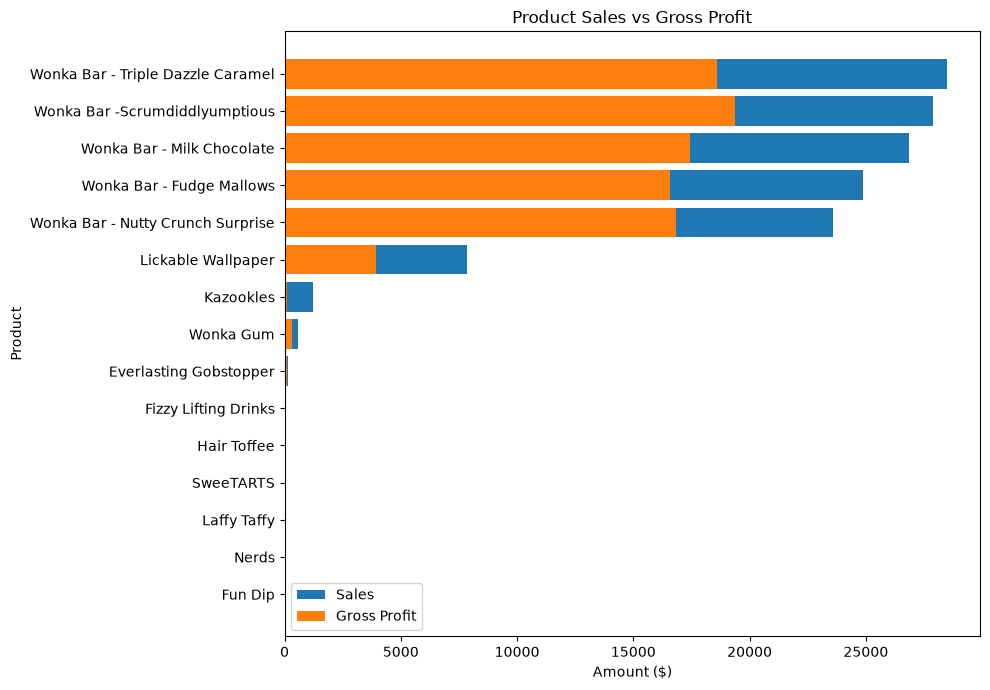

In [13]:
import matplotlib.pyplot as plt

# Sort products by sales
plot_data = product_analysis.sort_values("Sales", ascending=True)

plt.figure(figsize=(10, 7))

plt.barh(
    plot_data.index,
    plot_data["Sales"],
    label="Sales"
)

plt.barh(
    plot_data.index,
    plot_data["Gross_Profit"],
    label="Gross Profit"
)

plt.xlabel("Amount ($)")
plt.ylabel("Product")
plt.title("Product Sales vs Gross Profit")
plt.legend()
plt.tight_layout()
plt.show()

In [14]:
# REGIONAL SHIPPING PERFORMANCE

region_analysis = (
    df.groupby("Region")
    .agg(
        Orders=("Order ID", "nunique"),
        Units=("Units", "sum"),
        Sales=("Sales", "sum"),
        Gross_Profit=("Gross Profit", "sum"),
        Avg_Lead_Time=("Lead Time", "mean")
    )
    .sort_values("Avg_Lead_Time", ascending=False)
)

region_analysis["Profit_Margin_%"] = (
    region_analysis["Gross_Profit"] /
    region_analysis["Sales"] * 100
)

region_analysis = region_analysis.round(2)

display(region_analysis)

,Orders,Units,Sales,Gross_Profit,Avg_Lead_Time,Profit_Margin_%
Region,,,,,,
Interior,1979,8820,32037.60,21282.49,1323.09,66.43
Atlantic,2476,11159,41197.24,26973.70,1322.75,65.47
Pacific,2744,12466,46301.53,30485.94,1322.19,65.84
Gulf,1350,6209,22247.26,14700.67,1311.37,66.08


In [15]:
# SHIP MODE PERFORMANCE

ship_mode_analysis = (
    df.groupby("Ship Mode")
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Units", "sum"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Avg_Lead_Time=("Lead Time", "mean")
      )
      .sort_values("Avg_Lead_Time", ascending=True)
)

ship_mode_analysis["Profit_Margin_%"] = (
    ship_mode_analysis["Gross_Profit"] /
    ship_mode_analysis["Sales"] * 100
)

ship_mode_analysis = ship_mode_analysis.round(2)

display(ship_mode_analysis)

,Orders,Units,Sales,Gross_Profit,Avg_Lead_Time,Profit_Margin_%
Ship Mode,,,,,,
Standard Class,5142,23409,85490.35,56424.46,1314.33,66.00
Second Class,1653,7546,27860.22,18306.52,1323.85,65.71
Same Day,442,1975,7113.67,4700.73,1333.44,66.08
First Class,1312,5724,21319.39,14011.09,1338.28,65.72


In [16]:
# PRODUCT + REGION SHIPPING PERFORMANCE

product_region_analysis = (
    df.groupby(["Product Name", "Region"])
      .agg(
          Orders=("Order ID", "nunique"),
          Units=("Units", "sum"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum"),
          Avg_Lead_Time=("Lead Time", "mean")
      )
      .reset_index()
)

product_region_analysis["Profit_Margin_%"] = (
    product_region_analysis["Gross_Profit"] /
    product_region_analysis["Sales"] * 100
)

product_region_analysis = product_region_analysis.round(2)

display(product_region_analysis)

,Product Name,Region,Orders,Units,Sales,Gross_Profit,Avg_Lead_Time,Profit_Margin_%
0,Everlasting Gobstopper,Gulf,1,4,40.00,32.00,1273.00,80.00
1,Everlasting Gobstopper,Interior,1,3,30.00,24.00,1641.00,80.00
2,Everlasting Gobstopper,Pacific,1,6,60.00,48.00,1270.00,80.00
3,Fizzy Lifting Drinks,Atlantic,2,9,33.75,20.25,1455.50,60.00
4,Fizzy Lifting Drinks,Gulf,1,4,15.00,9.00,909.00,60.00
5,Fizzy Lifting Drinks,Interior,2,5,18.75,11.25,1273.50,60.00
6,Fizzy Lifting Drinks,Pacific,1,3,11.25,6.75,1274.00,60.00
7,Fun Dip,Atlantic,1,4,6.00,2.40,1275.00,40.00
8,Fun Dip,Gulf,1,1,1.50,0.60,1272.00,40.00
9,Fun Dip,Interior,1,3,4.50,1.80,1271.00,40.00


In [17]:
# HIGH-VOLUME PRODUCT-REGION ROUTES

reliable_routes = (
    product_region_analysis[
        product_region_analysis["Orders"] >= 30
    ]
    .sort_values("Avg_Lead_Time", ascending=False)
)

display(reliable_routes)

,Product Name,Region,Orders,Units,Sales,Gross_Profit,Avg_Lead_Time,Profit_Margin_%
21,Lickable Wallpaper,Atlantic,34,139,2780.00,1390.00,1387.83,50.00
37,Wonka Bar - Nutty Crunch Surprise,Atlantic,410,1857,6480.93,4623.93,1360.43,71.35
44,Wonka Bar - Triple Dazzle Caramel,Pacific,571,2595,9731.25,6357.75,1332.13,65.33
35,Wonka Bar - Milk Chocolate,Interior,425,1869,6074.25,3943.59,1331.98,64.92
48,Wonka Bar -Scrumdiddlyumptious,Pacific,560,2468,8884.80,6170.00,1331.28,69.44
47,Wonka Bar -Scrumdiddlyumptious,Interior,380,1723,6202.80,4307.50,1329.91,69.44
39,Wonka Bar - Nutty Crunch Surprise,Interior,385,1694,5912.06,4218.06,1329.85,71.35
42,Wonka Bar - Triple Dazzle Caramel,Gulf,266,1223,4586.25,2996.35,1328.67,65.33
36,Wonka Bar - Milk Chocolate,Pacific,552,2706,8794.50,5709.66,1326.02,64.92
41,Wonka Bar - Triple Dazzle Caramel,Atlantic,463,2086,7822.50,5110.70,1323.58,65.33


In [18]:
# CURRENT PRODUCT-FACTORY MAPPING

factory_mapping = {
    "Wonka Bar - Nutty Crunch Surprise": "Lot's O' Nuts",
    "Wonka Bar - Fudge Mallows": "Lot's O' Nuts",
    "Wonka Bar -Scrumdiddlyumptious": "Lot's O' Nuts",
    "Wonka Bar - Milk Chocolate": "Wicked Choccy's",
    "Wonka Bar - Triple Dazzle Caramel": "Wicked Choccy's",
    "Laffy Taffy": "Sugar Shack",
    "SweeTARTS": "Sugar Shack",
    "Nerds": "Sugar Shack",
    "Fun Dip": "Sugar Shack",
    "Everlasting Gobstopper": "Secret Factory",
    "Hair Toffee": "The Other Factory",
    "Fizzy Lifting Drinks": "Sugar Shack",
    "Lickable Wallpaper": "Secret Factory",
    "Wonka Gum": "Secret Factory",
    "Kazookles": "The Other Factory"
}

df["Current Factory"] = df["Product Name"].map(factory_mapping)

print("Products in dataset:", df["Product Name"].nunique())
print("Products mapped:", df["Current Factory"].notna().sum())
print("Unmapped rows:", df["Current Factory"].isna().sum())

print("\nCurrent Factory Distribution:")
display(
    df.groupby("Current Factory")
      .agg(
          Products=("Product Name", "nunique"),
          Orders=("Order ID", "nunique"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum")
      )
      .round(2)
)

Products in dataset: 15
Products mapped: 10194
Unmapped rows: 0

Current Factory Distribution:


,Products,Orders,Sales,Gross_Profit
Current Factory,,,,
Lot's O' Nuts,3,4760,76340.15,52771.05
Secret Factory,3,213,8587.50,4344.70
Sugar Shack,5,33,220.98,121.23
The Other Factory,2,98,1282.25,152.25
Wicked Choccy's,2,3445,55352.75,36053.57


In [19]:
# FACTORY COORDINATES

factory_coordinates = {
    "Lot's O' Nuts": (32.881893, -111.768036),
    "Wicked Choccy's": (32.076176, -81.088371),
    "Sugar Shack": (48.119140, -96.181150),
    "Secret Factory": (41.446333, -90.565487),
    "The Other Factory": (35.117500, -89.971107)
}

print("Factories:", len(factory_coordinates))

for factory, (lat, lon) in factory_coordinates.items():
    print(f"{factory}: Latitude={lat}, Longitude={lon}")

Factories: 5
Lot's O' Nuts: Latitude=32.881893, Longitude=-111.768036
Wicked Choccy's: Latitude=32.076176, Longitude=-81.088371
Sugar Shack: Latitude=48.11914, Longitude=-96.18115
Secret Factory: Latitude=41.446333, Longitude=-90.565487
The Other Factory: Latitude=35.1175, Longitude=-89.971107


In [20]:
# REGION COORDINATES
# Approximate geographic center points used for distance-based analysis

region_coordinates = {
    "Atlantic": (39.0, -75.0),
    "Gulf": (29.5, -90.0),
    "Interior": (39.0, -100.0),
    "Pacific": (37.0, -120.0)
}

print("Region coordinates:")
for region, (lat, lon) in region_coordinates.items():
    print(f"{region}: Latitude={lat}, Longitude={lon}")

Region coordinates:
Atlantic: Latitude=39.0, Longitude=-75.0
Gulf: Latitude=29.5, Longitude=-90.0
Interior: Latitude=39.0, Longitude=-100.0
Pacific: Latitude=37.0, Longitude=-120.0


In [21]:
# FACTORY-TO-REGION DISTANCE MATRIX

from math import radians, sin, cos, sqrt, atan2

def haversine_distance(lat1, lon1, lat2, lon2):
    """
    Calculate distance between two geographic coordinates in kilometers.
    """
    R = 6371  # Earth's radius in km

    lat1, lon1, lat2, lon2 = map(
        radians, [lat1, lon1, lat2, lon2]
    )

    dlat = lat2 - lat1
    dlon = lon2 - lon1

    a = (
        sin(dlat / 2) ** 2
        + cos(lat1) * cos(lat2) * sin(dlon / 2) ** 2
    )

    c = 2 * atan2(sqrt(a), sqrt(1 - a))

    return R * c


distance_matrix = pd.DataFrame(
    index=factory_coordinates.keys(),
    columns=region_coordinates.keys(),
    dtype=float
)

for factory, (factory_lat, factory_lon) in factory_coordinates.items():

    for region, (region_lat, region_lon) in region_coordinates.items():

        distance_matrix.loc[factory, region] = haversine_distance(
            factory_lat,
            factory_lon,
            region_lat,
            region_lon
        )

distance_matrix = distance_matrix.round(2)

print("Factory-to-Region Distance Matrix (km):")
display(distance_matrix)

Factory-to-Region Distance Matrix (km):


,Atlantic,Gulf,Interior,Pacific
Lot's O' Nuts,3355.59,2100.53,1257.41,878.52
Wicked Choccy's,946.14,897.82,1871.57,3580.91
Sugar Shack,1975.47,2136.73,1059.31,2294.99
Secret Factory,1347.26,1329.35,845.39,2570.30
The Other Factory,1394.89,624.64,988.32,2696.28


In [22]:
# MODELING FEATURE PREPARATION

df["Factory_Region_Distance_km"] = [
    distance_matrix.loc[factory, region]
    for factory, region in zip(
        df["Current Factory"],
        df["Region"]
    )
]

model_features = df[
    [
        "Product Name",
        "Current Factory",
        "Region",
        "Ship Mode",
        "Sales",
        "Units",
        "Cost",
        "Gross Profit",
        "Factory_Region_Distance_km",
        "Lead Time"
    ]
].copy()

print("Modeling dataset shape:", model_features.shape)

print("\nMissing values:")
display(model_features.isna().sum())

print("\nModeling dataset preview:")
display(model_features.head())

Modeling dataset shape: (10194, 10)

Missing values:


Product Name                  0
Current Factory               0
Region                        0
Ship Mode                     0
Sales                         0
Units                         0
Cost                          0
Gross Profit                  0
Factory_Region_Distance_km    0
Lead Time                     0
dtype: int64


Modeling dataset preview:


,Product Name,Current Factory,Region,Ship Mode,Sales,Units,Cost,Gross Profit,Factory_Region_Distance_km,Lead Time
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,6.50,2,2.28,4.22,1871.57,909
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,7.50,2,2.60,4.90,1871.57,909
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,10.47,3,3.00,7.47,1257.41,909
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,10.80,3,3.30,7.50,1257.41,909
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,11.25,3,3.90,7.35,946.14,912


In [23]:
# TRAIN / TEST SPLIT

from sklearn.model_selection import train_test_split

X = model_features.drop(columns=["Lead Time"])
y = model_features["Lead Time"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train))
print("Testing rows:", len(X_test))
print("Training target mean:", round(y_train.mean(), 2))
print("Testing target mean:", round(y_test.mean(), 2))

Training rows: 8155
Testing rows: 2039
Training target mean: 1321.77
Testing target mean: 1317.14


In [24]:
# PREPROCESSING PIPELINE

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

categorical_features = [
    "Product Name",
    "Current Factory",
    "Region",
    "Ship Mode"
]

numerical_features = [
    "Sales",
    "Units",
    "Cost",
    "Gross Profit",
    "Factory_Region_Distance_km"
]

preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features
        )
    ]
)

print("Preprocessing pipeline created successfully!")

Preprocessing pipeline created successfully!


In [25]:
# TRANSFORM TRAINING AND TESTING DATA

X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Original training shape:", X_train.shape)
print("Processed training shape:", X_train_processed.shape)

print("Original testing shape:", X_test.shape)
print("Processed testing shape:", X_test_processed.shape)

Original training shape: (8155, 9)
Processed training shape: (8155, 33)
Original testing shape: (2039, 9)
Processed testing shape: (2039, 33)


In [26]:
# LINEAR REGRESSION BASELINE

from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

linear_model = LinearRegression()

linear_model.fit(
    X_train_processed,
    y_train
)

linear_predictions = linear_model.predict(X_test_processed)

linear_rmse = np.sqrt(
    mean_squared_error(y_test, linear_predictions)
)

linear_mae = mean_absolute_error(
    y_test,
    linear_predictions
)

linear_r2 = r2_score(
    y_test,
    linear_predictions
)

print("Linear Regression Results")
print("RMSE:", round(linear_rmse, 2))
print("MAE:", round(linear_mae, 2))
print("R²:", round(linear_r2, 4))

Linear Regression Results
RMSE: 266.74
MAE: 215.19
R²: -0.0061


In [27]:
# RANDOM FOREST REGRESSOR

from sklearn.ensemble import RandomForestRegressor

random_forest_model = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model.fit(
    X_train_processed,
    y_train
)

rf_predictions = random_forest_model.predict(
    X_test_processed
)

rf_rmse = np.sqrt(
    mean_squared_error(y_test, rf_predictions)
)

rf_mae = mean_absolute_error(
    y_test,
    rf_predictions
)

rf_r2 = r2_score(
    y_test,
    rf_predictions
)

print("Random Forest Results")
print("RMSE:", round(rf_rmse, 2))
print("MAE:", round(rf_mae, 2))
print("R²:", round(rf_r2, 4))

Random Forest Results
RMSE: 276.84
MAE: 224.59
R²: -0.0837


In [28]:
# GRADIENT BOOSTING REGRESSOR

from sklearn.ensemble import GradientBoostingRegressor

gradient_boosting_model = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model.fit(
    X_train_processed,
    y_train
)

gb_predictions = gradient_boosting_model.predict(
    X_test_processed
)

gb_rmse = np.sqrt(
    mean_squared_error(y_test, gb_predictions)
)

gb_mae = mean_absolute_error(
    y_test,
    gb_predictions
)

gb_r2 = r2_score(
    y_test,
    gb_predictions
)

print("Gradient Boosting Results")
print("RMSE:", round(gb_rmse, 2))
print("MAE:", round(gb_mae, 2))
print("R²:", round(gb_r2, 4))

Gradient Boosting Results
RMSE: 267.67
MAE: 215.79
R²: -0.0131


In [29]:
# LEAD TIME DISTRIBUTION

print("Lead Time Statistics:")
display(df["Lead Time"].describe())

print("\nMost common Lead Time values:")
display(
    df["Lead Time"]
    .value_counts()
    .head(15)
    .sort_index()
)

Lead Time Statistics:


count    10194.000000
mean      1320.841868
std        262.444892
min        904.000000
25%       1271.000000
50%       1274.000000
75%       1638.000000
max       1642.000000
Name: Lead Time, dtype: float64


Most common Lead Time values:


Lead Time
906      289
908      591
909      519
1269     258
1271     610
1272     456
1273    1326
1274    1035
1275     612
1276     293
1637     449
1638     411
1639     896
1640     657
1641     397
Name: count, dtype: int64

In [30]:
# LEAD TIME PATTERN BY ORDER YEAR AND MONTH

lead_time_year = (
    df.groupby("Order Year")
      .agg(
          Orders=("Order ID", "count"),
          Avg_Lead_Time=("Lead Time", "mean"),
          Min_Lead_Time=("Lead Time", "min"),
          Max_Lead_Time=("Lead Time", "max")
      )
      .round(2)
)

print("Lead Time by Order Year:")
display(lead_time_year)

print("\nLead Time by Order Month:")
display(
    df.groupby("Order Month")["Lead Time"]
      .agg(["count", "mean", "min", "max"])
      .round(2)
)

Lead Time by Order Year:


,Orders,Avg_Lead_Time,Min_Lead_Time,Max_Lead_Time
Order Year,,,,
2024,4181,1094.02,904,1277
2025,6013,1478.56,1269,1642



Lead Time by Order Month:


,count,mean,min,max
Order Month,,,,
1,404,1343.09,906,1641
2,300,1347.66,905,1642
3,711,1317.19,904,1642
4,670,1311.05,904,1642
5,758,1328.58,904,1642
6,725,1328.64,904,1642
7,718,1317.46,904,1642
8,722,1306.23,904,1642
9,1399,1323.38,904,1642


In [31]:
# IMPROVED MODEL FEATURES

model_features_v2 = df[
    [
        "Product Name",
        "Current Factory",
        "Region",
        "Ship Mode",
        "Order Year",
        "Order Month",
        "Factory_Region_Distance_km",
        "Lead Time"
    ]
].copy()

print("Improved modeling dataset shape:", model_features_v2.shape)

display(model_features_v2.head())

Improved modeling dataset shape: (10194, 8)


,Product Name,Current Factory,Region,Ship Mode,Order Year,Order Month,Factory_Region_Distance_km,Lead Time
0,Wonka Bar - Milk Chocolate,Wicked Choccy's,Interior,Standard Class,2024,1,1871.57,909
1,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Interior,Standard Class,2024,1,1871.57,909
2,Wonka Bar - Nutty Crunch Surprise,Lot's O' Nuts,Interior,Standard Class,2024,1,1257.41,909
3,Wonka Bar -Scrumdiddlyumptious,Lot's O' Nuts,Interior,Standard Class,2024,1,1257.41,909
4,Wonka Bar - Triple Dazzle Caramel,Wicked Choccy's,Atlantic,Standard Class,2024,1,946.14,912


In [32]:
# IMPROVED TRAIN / TEST SPLIT

X_v2 = model_features_v2.drop(columns=["Lead Time"])
y_v2 = model_features_v2["Lead Time"]

X_train_v2, X_test_v2, y_train_v2, y_test_v2 = train_test_split(
    X_v2,
    y_v2,
    test_size=0.20,
    random_state=42
)

print("Training rows:", len(X_train_v2))
print("Testing rows:", len(X_test_v2))
print("Training target mean:", round(y_train_v2.mean(), 2))
print("Testing target mean:", round(y_test_v2.mean(), 2))

Training rows: 8155
Testing rows: 2039
Training target mean: 1321.77
Testing target mean: 1317.14


In [33]:
# IMPROVED PREPROCESSING PIPELINE

categorical_features_v2 = [
    "Product Name",
    "Current Factory",
    "Region",
    "Ship Mode"
]

numerical_features_v2 = [
    "Order Year",
    "Order Month",
    "Factory_Region_Distance_km"
]

preprocessor_v2 = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numerical_features_v2
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore",
                sparse_output=False
            ),
            categorical_features_v2
        )
    ]
)

print("Improved preprocessing pipeline created successfully!")

Improved preprocessing pipeline created successfully!


In [34]:
# TRANSFORM IMPROVED TRAINING AND TESTING DATA

X_train_processed_v2 = preprocessor_v2.fit_transform(X_train_v2)
X_test_processed_v2 = preprocessor_v2.transform(X_test_v2)

print("Original training shape:", X_train_v2.shape)
print("Processed training shape:", X_train_processed_v2.shape)

print("Original testing shape:", X_test_v2.shape)
print("Processed testing shape:", X_test_processed_v2.shape)

Original training shape: (8155, 7)
Processed training shape: (8155, 31)
Original testing shape: (2039, 7)
Processed testing shape: (2039, 31)


In [35]:
# IMPROVED LINEAR REGRESSION

linear_model_v2 = LinearRegression()

linear_model_v2.fit(
    X_train_processed_v2,
    y_train_v2
)

linear_predictions_v2 = linear_model_v2.predict(
    X_test_processed_v2
)

linear_rmse_v2 = np.sqrt(
    mean_squared_error(y_test_v2, linear_predictions_v2)
)

linear_mae_v2 = mean_absolute_error(
    y_test_v2,
    linear_predictions_v2
)

linear_r2_v2 = r2_score(
    y_test_v2,
    linear_predictions_v2
)

print("Improved Linear Regression Results")
print("RMSE:", round(linear_rmse_v2, 2))
print("MAE:", round(linear_mae_v2, 2))
print("R²:", round(linear_r2_v2, 4))

Improved Linear Regression Results
RMSE: 182.43
MAE: 181.41
R²: 0.5294


In [36]:
# IMPROVED RANDOM FOREST

random_forest_model_v2 = RandomForestRegressor(
    n_estimators=200,
    random_state=42,
    n_jobs=-1
)

random_forest_model_v2.fit(
    X_train_processed_v2,
    y_train_v2
)

rf_predictions_v2 = random_forest_model_v2.predict(
    X_test_processed_v2
)

rf_rmse_v2 = np.sqrt(
    mean_squared_error(y_test_v2, rf_predictions_v2)
)

rf_mae_v2 = mean_absolute_error(
    y_test_v2,
    rf_predictions_v2
)

rf_r2_v2 = r2_score(
    y_test_v2,
    rf_predictions_v2
)

print("Improved Random Forest Results")
print("RMSE:", round(rf_rmse_v2, 2))
print("MAE:", round(rf_mae_v2, 2))
print("R²:", round(rf_r2_v2, 4))

Improved Random Forest Results
RMSE: 192.47
MAE: 172.88
R²: 0.4762


In [37]:
# IMPROVED GRADIENT BOOSTING

gradient_boosting_model_v2 = GradientBoostingRegressor(
    n_estimators=200,
    learning_rate=0.05,
    max_depth=3,
    random_state=42
)

gradient_boosting_model_v2.fit(
    X_train_processed_v2,
    y_train_v2
)

gb_predictions_v2 = gradient_boosting_model_v2.predict(
    X_test_processed_v2
)

gb_rmse_v2 = np.sqrt(
    mean_squared_error(y_test_v2, gb_predictions_v2)
)

gb_mae_v2 = mean_absolute_error(
    y_test_v2,
    gb_predictions_v2
)

gb_r2_v2 = r2_score(
    y_test_v2,
    gb_predictions_v2
)

print("Improved Gradient Boosting Results")
print("RMSE:", round(gb_rmse_v2, 2))
print("MAE:", round(gb_mae_v2, 2))
print("R²:", round(gb_r2_v2, 4))

Improved Gradient Boosting Results
RMSE: 181.58
MAE: 179.96
R²: 0.5338


In [38]:
# FINAL MODEL COMPARISON

model_comparison = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "RMSE": [
        linear_rmse_v2,
        rf_rmse_v2,
        gb_rmse_v2
    ],
    "MAE": [
        linear_mae_v2,
        rf_mae_v2,
        gb_mae_v2
    ],
    "R2": [
        linear_r2_v2,
        rf_r2_v2,
        gb_r2_v2
    ]
})

model_comparison = model_comparison.round(4)

display(model_comparison)

best_model_name = model_comparison.loc[
    model_comparison["RMSE"].idxmin(),
    "Model"
]

print("Selected Best Model:", best_model_name)

,Model,RMSE,MAE,R2
0,Linear Regression,182.4283,181.4057,0.5294
1,Random Forest,192.4734,172.8815,0.4762
2,Gradient Boosting,181.5811,179.9607,0.5338


Selected Best Model: Gradient Boosting


In [39]:
# ROUTE PERFORMANCE DATASET

route_performance = (
    df.groupby(["Product Name", "Region"])
      .agg(
          Orders=("Order ID", "nunique"),
          Avg_Lead_Time=("Lead Time", "mean"),
          Sales=("Sales", "sum"),
          Gross_Profit=("Gross Profit", "sum")
      )
      .reset_index()
)

route_performance["Profit_Margin_%"] = (
    route_performance["Gross_Profit"]
    / route_performance["Sales"]
) * 100

# Keep routes with enough orders for reliable analysis
route_performance_reliable = (
    route_performance[
        route_performance["Orders"] >= 30
    ]
    .sort_values("Avg_Lead_Time", ascending=False)
    .reset_index(drop=True)
)

print("Total product-region combinations:",
      len(route_performance))

print("Reliable combinations:",
      len(route_performance_reliable))

display(route_performance_reliable.head(10))

Total product-region combinations: 53
Reliable combinations: 24


,Product Name,Region,Orders,Avg_Lead_Time,Sales,Gross_Profit,Profit_Margin_%
0,Lickable Wallpaper,Atlantic,34,1387.828571,2780.00,1390.00,50.000000
1,Wonka Bar - Nutty Crunch Surprise,Atlantic,410,1360.426531,6480.93,4623.93,71.346705
2,Wonka Bar - Triple Dazzle Caramel,Pacific,571,1332.133136,9731.25,6357.75,65.333333
3,Wonka Bar - Milk Chocolate,Interior,425,1331.977956,6074.25,3943.59,64.923077
4,Wonka Bar -Scrumdiddlyumptious,Pacific,560,1331.282738,8884.80,6170.00,69.444444
5,Wonka Bar -Scrumdiddlyumptious,Interior,380,1329.908497,6202.80,4307.50,69.444444
6,Wonka Bar - Nutty Crunch Surprise,Interior,385,1329.847345,5912.06,4218.06,71.346705
7,Wonka Bar - Triple Dazzle Caramel,Gulf,266,1328.669697,4586.25,2996.35,65.333333
8,Wonka Bar - Milk Chocolate,Pacific,552,1326.024024,8794.50,5709.66,64.923077
9,Wonka Bar - Triple Dazzle Caramel,Atlantic,463,1323.578853,7822.50,5110.70,65.333333
